# JJ connected current-current correlator -- analysis (tp projection)

Mimics `meson_wall_various_ell_nu1tuning_claude_v2.ipynb` for the conserved-current $G(t)$
produced by `jj_conn_tpproj_claude.cu`.  Files: `data_<ESNID>/tp_<current>/conn.<k>.<h>.h5`
with datasets `Vpp/{real,imag}`, `Vmm/{real,imag}` (length $N_t$).  Here a 'sample' = one
`conn.*.*.h5` file (= a hit for free-field / a config for an ensemble); jackknife over them.

In [1]:
import h5py
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize

import glob

from natsort import natsorted

In [2]:
class Jackknife:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins
        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins - 1

    def mean( self ): return self.est
    def var( self ):  return self.var_est
    def err( self ):  return np.sqrt(self.var_est)

# resampling estimators (data shape = (nsamples, Nt))
def simple_mean(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    return np.mean(resmpld, axis=0)

def jack_avg(i, binsize, np_data):
    return np_data[i]

def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1) >= err > 10**(-i):
            tmp = err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1) >= err > 10**(-i):
            tmp = err*10**(i+1)
            return ('{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'
                    +': '+'{num:.{width}f}'.format(num=(exact-cen)/err, width=i+1)+' sigma')

In [ ]:
# ---- parameters (match the run / CLI) ----
gsq = "8.000000"
at  = "0.200000"
Nt  = 128
L   = 1
Nf  = 2
nu0 = "1.000000"

current = "vector"   # tp_<current>

# ---- free vs interacting ensemble knob ----
# ens = 'free'  -> free-field check (U=1):   data_free_vmRe<mre>vmIm<mim>/...
# ens = <basename of --ens-dir used in the run> -> interacting sea ensemble, e.g.
#   'Nf2_gsq8.000000_nu01.000000_at0.200000_nt128L1'   (the LAST path component of --ens-dir;
#   esnid = <basename> + '_vmRe<mre>vmIm<mim>').  All loaders below default to this `ens`.
ens = 'free'

# n_t0 / nhits select the output subdir <proj>_<current>_nt0<N>_nhits<H> (and corr_nt0<N>_nhits<H>).
# Each corr.<k>.h5 holds every (h, t0) raw under /h{h}/t0_{b}/...; the loaders average over
# (h, t0) -> ONE row per config, then we jackknife over configs.
n_t0    = 2          # match --n-t0 used in the run
# nhits   = 16       # OLD (standalone tp_vector default); the vector tp conn data is now read from
nhits   = 64         # the COMBINED corr_nt0<N>_nhits<H>/ output (free --all run used --nhits 64)
binsize = 1

dir1 = '/mnt/barracuda22/qed3/qed3/src/both_3d/'

# ---- echo the resolved ensemble id / target directory (esnid = ens + '_vmRe<mre>vmIm<mim>') ----
print('ens =', repr(ens), '(free-field U=1)' if ens == 'free' else '(interacting sea ensemble)')
print('ensemble id (esnid) = %s_vmRe<mre>vmIm<mim>' % ens)
print('conn data dir       = %sdata_%s_vmRe<mre>vmIm<mim>/corr_nt0%d_nhits%d/' % (dir1, ens, n_t0, nhits))

In [4]:
# ---- .h5 completeness check (SAME gate as the programs' resume-skip in jj_conn_*_claude.cu) ----
# HighFive writes datasets sequentially, so a file is COMPLETE iff its LAST-written key is present.
# The programs probe exactly that key before skipping; we mirror it here (and require last-axis Nt).
# Last key = /h{nhits-1}/t0_{n_t0-1}/<last leaf>: leaves[-1] = 'Vmm/imag' (vector) or 'Apm/imag' (axial).
VKEYS = ['Vpp/real', 'Vpp/imag', 'Vmm/real', 'Vmm/imag']   # vector file: leaves[-1]='Vmm/imag'
AKEYS = ['Apm/real', 'Apm/imag']                            # axial  file: leaves[-1]='Apm/imag'

def list_ht0(f):
    '''All (h-key, t0-key) group pairs present in an n_t0 file, sorted.'''
    out = []
    for hk in natsorted(k for k in f.keys() if k.startswith('h') and k[1:].isdigit()):
        for tk in natsorted(k for k in f[hk].keys() if k.startswith('t0_')):
            out.append((hk, tk))
    return out

def h5_complete(fn, leaves, length=None):
    '''True iff fn opens, declares nhits/n_t0, and its LAST sequential key
       /h{nhits-1}/t0_{n_t0-1}/{leaves[-1]} exists with last-axis length Nt.
       (Same skip gate the .cu use: sequential writes -> last key present => whole config there.)'''
    if length is None: length = Nt
    try:
        with h5py.File(fn, 'r') as f:
            if 'nhits' not in f or 'n_t0' not in f:
                return False
            nh  = int(f['nhits'][0]); nt0 = int(f['n_t0'][0])
            last = 'h%d/t0_%d/%s' % (nh - 1, nt0 - 1, leaves[-1])
            if last not in f:
                return False
            if f[last].shape[-1] != length:
                return False
    except (OSError, KeyError):
        return False
    return True

In [5]:
# ---- jackknife helper + SIGNED log-axis plotters (no abs) ----
def jk_of(arr):
    jk = Jackknife(arr.shape[0], binsize)
    jk.set(simple_mean, arr)
    jk.do_it()
    return jk

# Shared y-range for all signed correlator plots (tune to taste).
YLIM = (1e-11, 1e-1)

# On a log axis a signed quantity is shown by drawing BOTH +y and -y; matplotlib drops the
# non-positive branch, so whichever sign is positive is the one visible.  The + and - branches
# get DISTINCT colors (cp / cm).
def plot_pm(ax, x, y, label, cp='C0', cm='C3'):
    ax.plot(x,  y, ls='solid', color=cp, label='+' + label)
    ax.plot(x, -y, ls='--',    color=cm, label='-' + label)

def ebar_pm(ax, x, y, e, label, cp='C0', cm='C3'):
    ax.errorbar(x,  y, e, ls='solid', capsize=2.0, color=cp, label='+' + label)
    ax.errorbar(x, -y, e, ls='--',    capsize=2.0, color=cm, label='-' + label)

In [ ]:
# ---- ESNID + loader.  esnid mirrors jj_corr_claude.cu:
#   esnid = (free?'free':<ens_basename>) + '_vmRe'+to_string(mre)+'vmIm'+to_string(mim)
#   (std::to_string -> 6 decimals).  `ens` is the block-3 knob (free vs interacting basename).
def esnid(mre, mim, ens=ens):
    return ens + '_vmRe' + '%.6f' % mre + 'vmIm' + '%.6f' % mim

# OLD: standalone tp_<current>_nt0<N>_nhits<H>/ (conn.*.h5, leaf 'Vpp').  tp_vector_nt02_nhits64
#   does NOT exist; the vector tp conn data now lives in the COMBINED jj_corr output.  Kept for reference:
# def conn_dir(mre, mim, ens='free'):
#     return dir1 + 'data_' + esnid(mre, mim, ens) + '/tp_' + current \
#                 + '_nt0' + str(n_t0) + '_nhits' + str(nhits) + '/'
# NEW: data_<esnid>/corr_nt0<N>_nhits<H>/corr.<k>.h5, vector tp under leaf 'tp/Vpp' (note the 'tp/'
#   projection level), gated by the global 'complete' sentinel (jj_corr writes sp/ylm/axial/disc AFTER
#   tp, then 'complete' LAST -- so the last-(h,t0)-key gate is NOT valid here; use the sentinel).
def conn_dir(mre, mim, ens=ens):
    return dir1 + 'data_' + esnid(mre, mim, ens) \
                + '/corr_nt0' + str(n_t0) + '_nhits' + str(nhits) + '/'

def _load_scalar(path, leaf, leaves):
    '''One row per COMPLETE conn.*.h5: the (h,t0)-average of the length-Nt dataset `leaf`.
       UNCHANGED -- still used by the axial (load_ax) and sp (load_sp) STANDALONE loaders, which
       read conn.*.h5 with the last-(h,t0)-key completeness gate.'''
    files = natsorted(glob.glob(path + 'conn.*.h5'))
    data, bad = [], []
    for fn in files:
        if not h5_complete(fn, leaves):
            bad.append(os.path.basename(fn)); continue
        with h5py.File(fn, 'r') as f:
            arrs = [ f[hk + '/' + tk + '/' + leaf][:] for (hk, tk) in list_ht0(f) ]
            data.append(np.mean(arrs, axis=0))
    if bad:
        print('  [load] skipped %d incomplete file(s) in %s: %s' % (len(bad), path, bad))
    return np.array(data)

# OLD vector tp loader (standalone conn.*.h5, leaf channel/part); kept for reference:
# def load(mre, mim, ens='free', channel='Vpp', part='real', keys=VKEYS):
#     return _load_scalar(conn_dir(mre, mim, ens), channel + '/' + part, keys)
# NEW vector tp loader: read corr.*.h5, gate on the 'complete' sentinel, average leaf 'tp/<chan>/<part>'
#   over all (h, t0) -> one row per config.  Own loop, so the shared _load_scalar above is untouched.
def load(mre, mim, ens=ens, channel='Vpp', part='real', keys=None):
    '''Return array (nconfig, Nt): one (h,t0)-averaged row per complete corr.<k>.h5 (vector tp leaf).'''
    path  = conn_dir(mre, mim, ens)
    files = natsorted(glob.glob(path + 'corr.*.h5'))
    leaf  = 'tp/' + channel + '/' + part
    data, bad = [], []
    for fn in files:
        try:
            with h5py.File(fn, 'r') as f:
                if 'complete' not in f:
                    bad.append(os.path.basename(fn)); continue
                arrs = [ f[hk + '/' + tk + '/' + leaf][:] for (hk, tk) in list_ht0(f) ]
                data.append(np.mean(arrs, axis=0))
        except (OSError, KeyError):
            bad.append(os.path.basename(fn))
    if bad:
        print('  [load] skipped %d incomplete/bad file(s) in %s: %s' % (len(bad), path, bad))
    return np.array(data)

xxx = float(at) * np.arange(Nt)

In [7]:
# ---- valence masses to compare (mre = m_F real, mim = m_P imaginary) ----
masses = [ (0.0, 0.0), (0.1, 0.0), (0.0, 0.1) ]   # massless, m_F, m_P
# masses = [ (m, 0.0) for m in [0.01,0.05,0.1,0.2] ]   # m_F sweep
# masses = [ (0.0, m) for m in [0.01,0.05,0.1,0.2] ]   # m_P sweep

# Re and Im kept separately (shape (nsamples, Nt)) so the SIGN is preserved for the plots below.
vppR = {}; vppI = {}
vmmR = {}; vmmI = {}
for (mre, mim) in masses:
    vppR[(mre,mim)] = load(mre, mim, channel='Vpp', part='real')
    vppI[(mre,mim)] = load(mre, mim, channel='Vpp', part='imag')
    vmmR[(mre,mim)] = load(mre, mim, channel='Vmm', part='real')
    vmmI[(mre,mim)] = load(mre, mim, channel='Vmm', part='imag')
    print(mre, mim, '  nsamples x Nt =', vppR[(mre,mim)].shape)

0.0 0.0   nsamples x Nt = (1, 128)
0.1 0.0   nsamples x Nt = (1, 128)
0.0 0.1   nsamples x Nt = (1, 128)


### Sign check (no `abs`)

Plots show the **signed** correlator on a log axis by drawing both $+G$ (solid) and $-G$ (dashed);
whichever sign is positive is the visible branch.  CFT prediction for the conserved vector current
(PDF Sec. 4.3): the **temporal** projection computed here is **negative**,
$$
G_t(t) = -C_J\,e^{-\Delta t}(1-e^{-t})^{-2\Delta},\qquad \Delta = D-1 = 2
$$
(Eq. 4.31), so $\mathrm{Re}\,G_{++}(t)<0$ and the **dashed ($-$) branch should be the visible one**.
The spatial projection $G_s = +C_j(D-1)e^{-\Delta t}(1-e^{-t})^{-2\Delta}>0$ (Eq. 4.28) is the
opposite sign -- a cross-check once `spproj` exists.  Imaginary parts $\approx 0$ for massless /
$m_F$; a nonzero Im is the parity-breaking signal ($m_P$).

In [8]:
# ---- (commented: no-errorbar mean overview; the per-mass errorbar cells below are the ones used) ----
# fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# for (mre, mim) in masses:
#     lbl = 'm=(%.2f,%.2f)' % (mre, mim)
#     plot_pm(ax[0], xxx, np.mean(vppR[(mre,mim)], axis=0), lbl)
#     plot_pm(ax[1], xxx, np.mean(vppI[(mre,mim)], axis=0), lbl)
# for a, lab in zip(ax, ['Re $G_{++}$', 'Im $G_{++}$']):
#     a.set_yscale('log'); a.set_xlabel('$t$ (a.u.)'); a.set_ylabel('|' + lab + '|')
#     a.set_title(lab + '   (+ solid, - dashed)'); a.legend(fontsize=8)
# plt.tight_layout()

/home/nobu/miniconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nobu/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


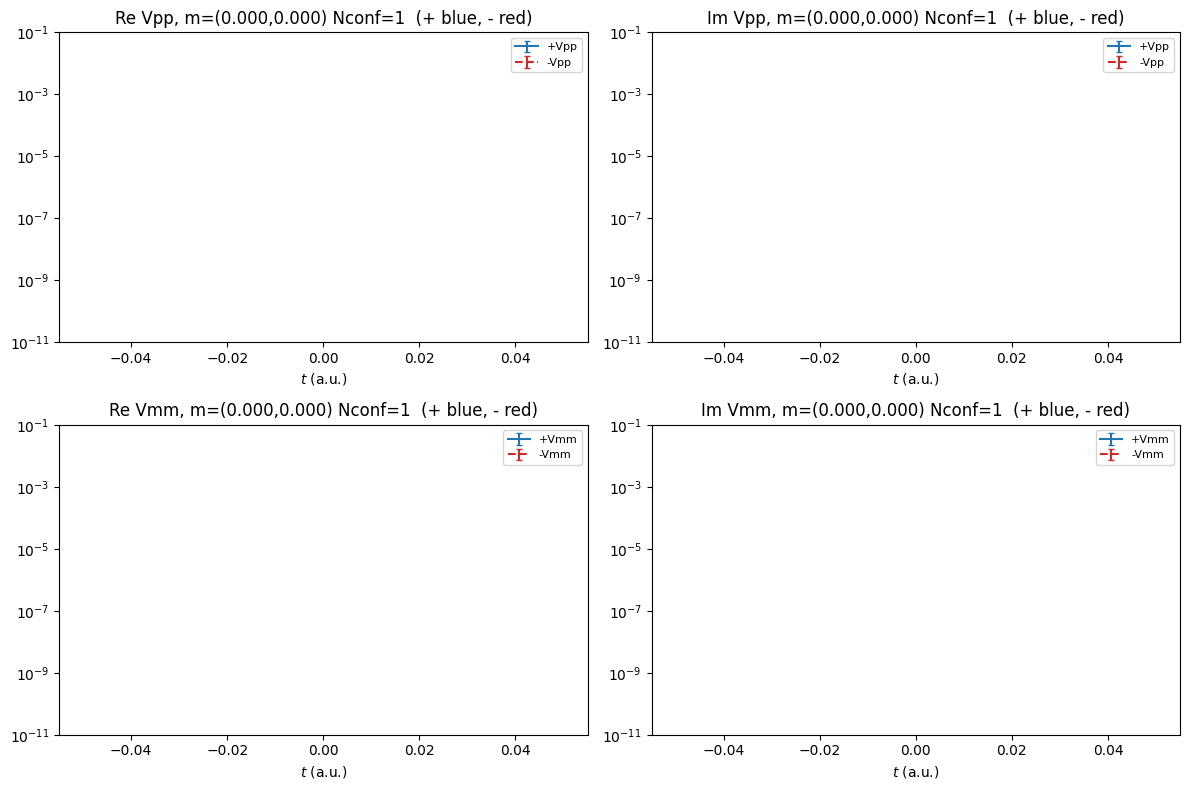

In [9]:
# ---- jackknife, SIGNED Re/Im for ONE mass; Vpp and Vmm on SEPARATE rows (no abs).  Expect Re < 0. ----
mre, mim = masses[0]
nconf = vppR[(mre,mim)].shape[0]
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
jkR_pp = jk_of(vppR[(mre,mim)]); jkI_pp = jk_of(vppI[(mre,mim)])
jkR_mm = jk_of(vmmR[(mre,mim)]); jkI_mm = jk_of(vmmI[(mre,mim)])
ebar_pm(ax[0][0], xxx, jkR_pp.mean(), jkR_pp.err(), 'Vpp')
ebar_pm(ax[0][1], xxx, jkI_pp.mean(), jkI_pp.err(), 'Vpp')
ebar_pm(ax[1][0], xxx, jkR_mm.mean(), jkR_mm.err(), 'Vmm')
ebar_pm(ax[1][1], xxx, jkI_mm.mean(), jkI_mm.err(), 'Vmm')
titles = [['Re Vpp', 'Im Vpp'], ['Re Vmm', 'Im Vmm']]
for i in range(2):
    for j in range(2):
        ax[i][j].set_yscale('log'); ax[i][j].set_ylim(YLIM); ax[i][j].set_xlabel('$t$ (a.u.)')
        ax[i][j].set_title('%s, m=(%.3f,%.3f) Nconf=%d  (+ blue, - red)' % (titles[i][j], mre, mim, nconf))
        ax[i][j].legend(fontsize=8)
plt.tight_layout()

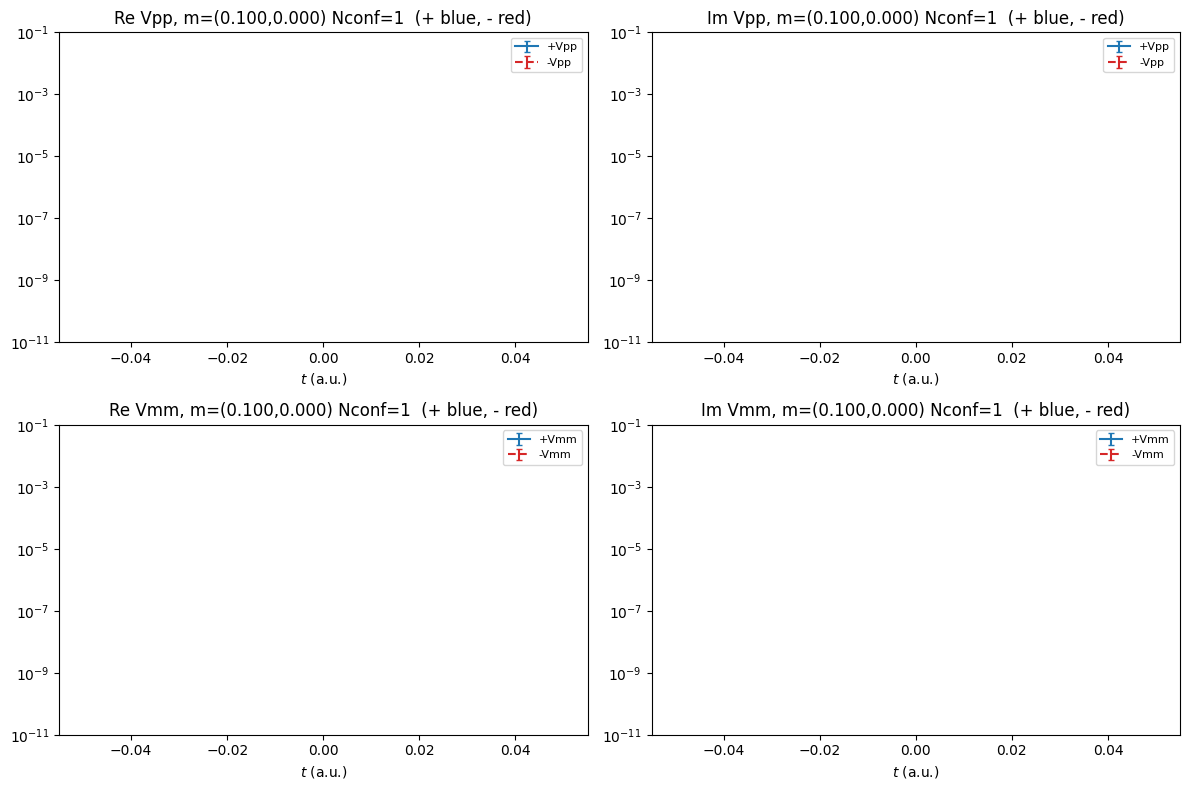

In [10]:
# ---- jackknife, SIGNED Re/Im for ONE mass; Vpp and Vmm on SEPARATE rows (no abs).  Expect Re < 0. ----
mre, mim = masses[1]
nconf = vppR[(mre,mim)].shape[0]
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
jkR_pp = jk_of(vppR[(mre,mim)]); jkI_pp = jk_of(vppI[(mre,mim)])
jkR_mm = jk_of(vmmR[(mre,mim)]); jkI_mm = jk_of(vmmI[(mre,mim)])
ebar_pm(ax[0][0], xxx, jkR_pp.mean(), jkR_pp.err(), 'Vpp')
ebar_pm(ax[0][1], xxx, jkI_pp.mean(), jkI_pp.err(), 'Vpp')
ebar_pm(ax[1][0], xxx, jkR_mm.mean(), jkR_mm.err(), 'Vmm')
ebar_pm(ax[1][1], xxx, jkI_mm.mean(), jkI_mm.err(), 'Vmm')
titles = [['Re Vpp', 'Im Vpp'], ['Re Vmm', 'Im Vmm']]
for i in range(2):
    for j in range(2):
        ax[i][j].set_yscale('log'); ax[i][j].set_ylim(YLIM); ax[i][j].set_xlabel('$t$ (a.u.)')
        ax[i][j].set_title('%s, m=(%.3f,%.3f) Nconf=%d  (+ blue, - red)' % (titles[i][j], mre, mim, nconf))
        ax[i][j].legend(fontsize=8)
plt.tight_layout()

In [ ]:
# ---- jackknife, SIGNED Re/Im for ONE mass; Vpp and Vmm on SEPARATE rows (no abs).  m_P: Im is the parity signal. ----
mre, mim = masses[2]
nconf = vppR[(mre,mim)].shape[0]
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
jkR_pp = jk_of(vppR[(mre,mim)]); jkI_pp = jk_of(vppI[(mre,mim)])
jkR_mm = jk_of(vmmR[(mre,mim)]); jkI_mm = jk_of(vmmI[(mre,mim)])
ebar_pm(ax[0][0], xxx, jkR_pp.mean(), jkR_pp.err(), 'Vpp')
ebar_pm(ax[0][1], xxx, jkI_pp.mean(), jkI_pp.err(), 'Vpp')
ebar_pm(ax[1][0], xxx, jkR_mm.mean(), jkR_mm.err(), 'Vmm')
ebar_pm(ax[1][1], xxx, jkI_mm.mean(), jkI_mm.err(), 'Vmm')
titles = [['Re Vpp', 'Im Vpp'], ['Re Vmm', 'Im Vmm']]
for i in range(2):
    for j in range(2):
        ax[i][j].set_yscale('log'); ax[i][j].set_ylim(YLIM); ax[i][j].set_xlabel('$t$ (a.u.)')
        ax[i][j].set_title('%s, m=(%.3f,%.3f) Nconf=%d  (+ blue, - red)' % (titles[i][j], mre, mim, nconf))
        ax[i][j].legend(fontsize=8)
plt.tight_layout()

In [ ]:
# ---- Im part + parity cross-check ----
# Non-parity (massless / m_F): the program writes Vmm = conj(Vpp) (mmRe=ppRe, mmIm=-ppIm),
#   so Vmm - conj(Vpp) == 0 to machine precision -- a write / round-trip sanity check.
# Parity (m_P): Vmm is computed INDEPENDENTLY via tilde D_{m_P}, so Vmm - conj(Vpp) is the
#   genuine parity-breaking signal (nonzero).
mre, mim = masses[0]
ppR = np.mean(load(mre, mim, channel='Vpp', part='real'), axis=0)
ppI = np.mean(load(mre, mim, channel='Vpp', part='imag'), axis=0)
mmR = np.mean(load(mre, mim, channel='Vmm', part='real'), axis=0)
mmI = np.mean(load(mre, mim, channel='Vmm', part='imag'), axis=0)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# left: Re/Im of both channels
ax[0].plot(xxx, ppR,       label='Re Vpp')
ax[0].plot(xxx, ppI,       label='Im Vpp')
ax[0].plot(xxx, mmR, '--', label='Re Vmm')
ax[0].plot(xxx, mmI, '--', label='Im Vmm')
ax[0].set_xlabel('$t$ (a.u.)'); ax[0].set_title('m=(%.3f,%.3f)' % (mre, mim)); ax[0].legend()

# right: parity residual  Vmm - conj(Vpp) = (mmR - ppR) + i (mmI + ppI)
resR = mmR - ppR
resI = mmI + ppI
ax[1].plot(xxx, resR, label='Re(Vmm - conj Vpp)')
ax[1].plot(xxx, resI, label='Im(Vmm - conj Vpp)')
ax[1].set_xlabel('$t$ (a.u.)')
ax[1].set_title('parity residual (== 0 for massless / $m_F$)'); ax[1].legend()

print('max |Vmm - conj(Vpp)| =', np.max(np.abs(resR + 1j*resI)))

In [ ]:
# ---- effective mass from Re G_{++}(t) (cosh/periodic), jackknifed.  Sign cancels in the ratio. ----
mre, mim = masses[0]
jkR = jk_of(vppR[(mre,mim)])

def meff( cor ):
    avg = (cor[1:int(Nt/2)] + np.flip(cor[int(Nt/2)+1:])) / 2
    tmp = np.arccosh( avg / cor[int(Nt/2)] )   # ratio of like-signed values > 0, so Re G < 0 is fine
    return (-tmp[1:] + tmp[:-1]) / float(at)

xx = np.arange(1, int(Nt/2)-1) * float(at)

jk_M = [ meff(s) for s in jkR.jack_avg ]
jk_meff = Jackknife( len(jk_M), 1 )
jk_meff.set( jack_avg, jk_M )
jk_meff.do_it()

plt.errorbar( xx, jk_meff.mean(), jk_meff.err(), capsize=2.0, label='m=(%.3f,%.3f)' % (mre,mim) )
plt.ylim(0.0, 5.0)
plt.xlabel('$t$ (a.u.)'); plt.ylabel('$m_{eff}$'); plt.legend()

## Axial connected correlator $C_{A+-}$

Loads `data_<ESNID>/tp_axial/conn.*.*.h5` (dataset `Apm/{real,imag}`, length $N_t$) produced by
`jj_conn_tpproj_axial_claude.cu`.  Single complex channel $C_{A+-}(t)$ -- only the $+-$ ordering is
computed; $C_{A-+}(\Delta t)=C_{A+-}(N_t-\Delta t)$ by reflection downstream (Eq. 3.57).  Valence:
massless / $m_F$ use the massless $D_\text{ov}$ on **both** legs (no conserved axial current at
$m_F\neq0$ -> massless-limit expression); $m_P$ uses $\tilde D_{m_P}$ on the sink leg.

In [ ]:
# ---- axial loader (tp_axial_nt0<N>_nhits<H>, leaf Apm/{real,imag}; (h,t0)-averaged) ----
def conn_dir_ax(mre, mim, ens='free'):
    return dir1 + 'data_' + esnid(mre, mim, ens) \
                + '/tp_axial_nt0' + str(n_t0) + '_nhits' + str(nhits) + '/'

def load_ax(mre, mim, ens='free', part='real', keys=AKEYS):
    '''Return array (nconfig, Nt): one (h,t0)-averaged row per complete conn.<k>.h5.'''
    return _load_scalar(conn_dir_ax(mre, mim, ens), 'Apm/' + part, keys)

In [33]:
# ---- load axial C_{A+-} for the same masses ----
apmR = {}   # apmR[(mre,mim)] = (nsamples, Nt) real part of Apm
apmI = {}
for (mre, mim) in masses:
    apmR[(mre,mim)] = load_ax(mre, mim, part='real')
    apmI[(mre,mim)] = load_ax(mre, mim, part='imag')
    print(mre, mim, '  axial nsamples x Nt =', apmR[(mre,mim)].shape)

0.0 0.0   axial nsamples x Nt = (10, 128)
0.1 0.0   axial nsamples x Nt = (1, 128)
0.0 0.1   axial nsamples x Nt = (1, 128)


In [34]:
# ---- (commented: no-errorbar axial mean overview; the per-mass errorbar cell below is the one used) ----
# fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# for (mre, mim) in masses:
#     lbl = 'm=(%.2f,%.2f)' % (mre, mim)
#     plot_pm(ax[0], xxx, np.mean(apmR[(mre,mim)], axis=0), lbl)
#     plot_pm(ax[1], xxx, np.mean(apmI[(mre,mim)], axis=0), lbl)
# for a, lab in zip(ax, [r'Re $C_{A+-}$', r'Im $C_{A+-}$']):
#     a.set_yscale('log'); a.set_xlabel('$t$ (a.u.)'); a.set_ylabel('|' + lab + '|')
#     a.set_title(lab + '   (+ solid, - dashed)'); a.legend(fontsize=8)
# plt.tight_layout()

In [ ]:
# ---- jackknife, SIGNED Re/Im of C_{A+-} for each mass (no abs; rows = Re, Im) ----
fig, ax = plt.subplots(2, len(masses), figsize=(5*len(masses), 8), squeeze=False)
for j, (mre, mim) in enumerate(masses):
    nconf = apmR[(mre,mim)].shape[0]
    jkR = jk_of(apmR[(mre,mim)]); jkI = jk_of(apmI[(mre,mim)])
    ebar_pm(ax[0][j], xxx, jkR.mean(), jkR.err(), 'Re')
    ebar_pm(ax[1][j], xxx, jkI.mean(), jkI.err(), 'Im')
    for i, lab in enumerate(['Re', 'Im']):
        ax[i][j].set_yscale('log'); ax[i][j].set_ylim(YLIM); ax[i][j].set_xlabel('$t$ (a.u.)')
        ax[i][j].set_title('%s $C_{A+-}$, m=(%.3f,%.3f) Nconf=%d  (+ blue, - red)' % (lab, mre, mim, nconf))
        ax[i][j].legend(fontsize=8)
plt.tight_layout()

In [36]:
# ---- (commented: no-errorbar vector-vs-axial overview) ----
# mre, mim = masses[0]
# fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# plot_pm(ax, xxx, np.mean(vppR[(mre,mim)], axis=0), r'vector Re $G_{++}$')
# plot_pm(ax, xxx, np.mean(apmR[(mre,mim)], axis=0), r'axial Re $C_{A+-}$')
# ax.set_yscale('log'); ax.set_xlabel('$t$ (a.u.)'); ax.set_ylabel('|Re|')
# ax.set_title('vector vs axial, m=(%.3f,%.3f)   (+ solid, - dashed)' % (mre, mim)); ax.legend(fontsize=8)

In [ ]:
# ---- completeness audit: per mass, how many conn.<k>.h5 have the full (h,t0) key set ----
def audit(mre, mim, keys, subdir, ens='free'):
    path  = dir1 + 'data_' + esnid(mre, mim, ens) + '/' + subdir + '/'
    files = natsorted(glob.glob(path + 'conn.*.h5'))
    bad   = [os.path.basename(fn) for fn in files if not h5_complete(fn, keys)]
    print('m=(%.3f,%.3f) %-30s : %3d/%3d complete%s'
          % (mre, mim, subdir, len(files)-len(bad), len(files),
             '' if not bad else '   incomplete: ' + str(bad)))

sub = '_nt0' + str(n_t0) + '_nhits' + str(nhits)
for (mre, mim) in masses:
    audit(mre, mim, VKEYS, 'tp_vector' + sub)
for (mre, mim) in masses:
    audit(mre, mim, AKEYS, 'tp_axial' + sub)

## Spatial projection (sp)

Loads `data_<ESNID>/sp_<current>_tmax<T>/` (vector `Vpp`/`Vmm`) and `sp_axial_tmax<T>/` (`Apm`),
produced by `jj_conn_spproj{,_axial}_claude.cu`.  **CFT sign cross-check** (PDF Eq. 4.28): the spatial
projection is **positive**, $G_s = +C_j(D-1)e^{-\Delta t}(1-e^{-t})^{-2\Delta}>0$ -- **opposite** the
temporal $G_t<0$ (Eq. 4.31).  So `Re Vpp` here should be positive (the **+ blue/solid** branch
visible) with no contact sign-flip -- the clean control for the sign machinery.  *(Run the sp programs
first; these cells need `sp_*_tmax<T>` data.)*

In [ ]:
# ---- spatial (sp) loaders: data_<esnid>/sp_<...>_nt0<N>_nhits<H>/  (G_s expected POSITIVE, Eq 4.28) ----
def load_sp(mre, mim, ens='free', channel='Vpp', part='real'):
    path = dir1 + 'data_' + esnid(mre, mim, ens) + '/sp_' + current \
                + '_nt0' + str(n_t0) + '_nhits' + str(nhits) + '/'
    return _load_scalar(path, channel + '/' + part, VKEYS)

def load_sp_ax(mre, mim, ens='free', part='real'):
    path = dir1 + 'data_' + esnid(mre, mim, ens) \
                + '/sp_axial_nt0' + str(n_t0) + '_nhits' + str(nhits) + '/'
    return _load_scalar(path, 'Apm/' + part, AKEYS)

In [ ]:
# ---- load sp vector (Vpp/Vmm) and sp axial (Apm) for the same masses ----
svppR = {}; svppI = {}; svmmR = {}; svmmI = {}
sapmR = {}; sapmI = {}
for (mre, mim) in masses:
    svppR[(mre,mim)] = load_sp(mre, mim, channel='Vpp', part='real')
    svppI[(mre,mim)] = load_sp(mre, mim, channel='Vpp', part='imag')
    svmmR[(mre,mim)] = load_sp(mre, mim, channel='Vmm', part='real')
    svmmI[(mre,mim)] = load_sp(mre, mim, channel='Vmm', part='imag')
    sapmR[(mre,mim)] = load_sp_ax(mre, mim, part='real')
    sapmI[(mre,mim)] = load_sp_ax(mre, mim, part='imag')
    print(mre, mim, '  sp vector', svppR[(mre,mim)].shape, ' sp axial', sapmR[(mre,mim)].shape)

In [ ]:
# ---- sp vector jackknife, SIGNED Re/Im (no abs).  Expect Re > 0 (G_s>0): + blue (solid) visible. ----
chans = [('Re Vpp', svppR), ('Im Vpp', svppI), ('Re Vmm', svmmR), ('Im Vmm', svmmI)]
fig, ax = plt.subplots(len(masses), 4, figsize=(20, 4*len(masses)), squeeze=False)
for r, (mre, mim) in enumerate(masses):
    nconf = svppR[(mre,mim)].shape[0]
    for c, (lab, d) in enumerate(chans):
        jk = jk_of(d[(mre,mim)])
        ebar_pm(ax[r][c], xxx, jk.mean(), jk.err(), lab)
        ax[r][c].set_yscale('log'); ax[r][c].set_ylim(YLIM); ax[r][c].set_xlabel('$t$ (a.u.)')
        ax[r][c].set_title('%s sp, m=(%.3f,%.3f) Nconf=%d  (+ blue, - red)' % (lab, mre, mim, nconf))
        ax[r][c].legend(fontsize=8)
plt.tight_layout()

In [ ]:
# ---- sp axial jackknife, SIGNED Re/Im of C_{A+-} (no abs) ----
fig, ax = plt.subplots(2, len(masses), figsize=(5*len(masses), 8), squeeze=False)
for j, (mre, mim) in enumerate(masses):
    nconf = sapmR[(mre,mim)].shape[0]
    jkR = jk_of(sapmR[(mre,mim)]); jkI = jk_of(sapmI[(mre,mim)])
    ebar_pm(ax[0][j], xxx, jkR.mean(), jkR.err(), 'Re')
    ebar_pm(ax[1][j], xxx, jkI.mean(), jkI.err(), 'Im')
    for i, lab in enumerate(['Re', 'Im']):
        ax[i][j].set_yscale('log'); ax[i][j].set_ylim(YLIM); ax[i][j].set_xlabel('$t$ (a.u.)')
        ax[i][j].set_title('%s sp $C_{A+-}$, m=(%.3f,%.3f) Nconf=%d  (+ blue, - red)' % (lab, mre, mim, nconf))
        ax[i][j].legend(fontsize=8)
plt.tight_layout()

In [ ]:
# ---- tp vs sp sign cross-check: Re G_t (tp, expect <0) vs Re G_s (sp, expect >0), massless ----
mre, mim = masses[0]
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
plot_pm(ax, xxx, np.mean(vppR[(mre,mim)],  axis=0), r'tp Re $G_t$', cp='C0', cm='C3')
plot_pm(ax, xxx, np.mean(svppR[(mre,mim)], axis=0), r'sp Re $G_s$', cp='C2', cm='C1')
ax.set_yscale('log'); ax.set_ylim(YLIM); ax.set_xlabel('$t$ (a.u.)'); ax.set_ylabel('|Re|')
ax.set_title('tp $G_t<0$ (Eq 4.31) vs sp $G_s>0$ (Eq 4.28), m=(%.3f,%.3f)  (+ solid, - dashed)' % (mre, mim))
ax.legend(fontsize=8)

## Spherical-harmonic projection (ylm) -- m-summed tower

Loads `data_<ESNID>/ylm_<current>_nt0<N>_nhits<H>/` (per-$\ell$ tower `Vpp`/`Vmm` under
`h{h}/t0_{b}/<chan>/l{l}/{real,imag}`, plus `ls`) from `jj_conn_ylmproj_claude.cu` (vector, **m-summed**:
keep $\ell_1=\ell_2=\ell$, sum $m_1,m_2$ over $-\ell..\ell$ -> **one solve per $\ell$**).  Towers
$\ell=0,1,2$.  CFT conformal tower (Eqs. 4.34--4.35): $\ell=0$ vanishes (charge conservation),
$\ell=1\sim-e^{-2t}$ ($\Delta=2$), $\ell=2\sim-e^{-3t}$ -- negative like the temporal $G_t$.
Loaders average over $(h,t_0)$ per config, then jackknife configs.

In [ ]:
# ---- ylm tower loader: data_<esnid>/ylm_<current>_nt0<N>_nhits<H>/  tower G_l(t) (Sec. 3.6) ----
# Keys: /h{h}/t0_{b}/Vpp|Vmm/l{l}/real|imag.  Rebuild the per-l tower and average over (h,t0)
# -> ONE (n_ell, Nt) per config.
def conn_dir_ylm(mre, mim, ens='free'):
    return dir1 + 'data_' + esnid(mre, mim, ens) + '/ylm_' + current \
                + '_nt0' + str(n_t0) + '_nhits' + str(nhits) + '/'

def ylm_complete(fn):
    '''SAME gate as jj_conn_ylmproj_claude.cu: last key /h{nhits-1}/t0_{n_t0-1}/Vmm/l{ls[-1]}/imag (len Nt).'''
    try:
        with h5py.File(fn, 'r') as f:
            for k in ['ls', 'nhits', 'n_t0']:
                if k not in f: return False
            ls = f['ls'][:]; nh = int(f['nhits'][0]); nt0 = int(f['n_t0'][0])
            last = 'h%d/t0_%d/Vmm/l%d/imag' % (nh - 1, nt0 - 1, ls[-1])
            if last not in f or f[last].shape[-1] != Nt: return False
    except (OSError, KeyError):
        return False
    return True

def load_ylm(mre, mim, ens='free', channel='Vpp'):
    '''Return (G (nconfig, n_ell, Nt) complex, ls); (h,t0)-averaged per config; skips incomplete.'''
    path  = conn_dir_ylm(mre, mim, ens)
    files = natsorted(glob.glob(path + 'conn.*.h5'))
    data, ls = [], None
    for fn in files:
        if not ylm_complete(fn): continue
        with h5py.File(fn, 'r') as f:
            ls = f['ls'][:]; nl = len(ls); pairs = list_ht0(f)
            Gsum = np.zeros((nl, Nt), dtype=complex)
            for (hk, tk) in pairs:
                for li, l in enumerate(ls):
                    key = '%s/%s/%s/l%d/' % (hk, tk, channel, l)
                    Gsum[li, :] += f[key + 'real'][:] + 1j*f[key + 'imag'][:]
            data.append(Gsum / len(pairs))
    return np.array(data), ls

In [ ]:
# ---- load ylm Vpp tower for the masses ----
gylm = {}   # gylm[(mre,mim)] = (nconfig, n_ell, Nt) complex
ls = None
for (mre, mim) in masses:
    gylm[(mre,mim)], ls = load_ylm(mre, mim, channel='Vpp')
    print(mre, mim, '  ylm', gylm[(mre,mim)].shape)
if ls is not None:
    print('towers l =', ls.tolist())

In [ ]:
# ---- conformal tower G_l(t), m-summed (Sec. 3.6; Eqs 4.34-4.35) ----
# plot -Re G_l on log (G<0 for l>=1, so -Re>0 shows); l=0 ~ 0 (charge conservation)
mre, mim = masses[0]
G = gylm[(mre,mim)]                                        # (nconfig, n_ell, Nt)
nconf = G.shape[0]
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for li, l in enumerate(ls):
    jk = jk_of(G[:, li, :].real)
    ax.errorbar(xxx, -jk.mean(), jk.err(), capsize=2.0, label='l=%d  (-Re)' % l)
ax.set_yscale('log'); ax.set_ylim(YLIM); ax.set_xlabel('$t$ (a.u.)'); ax.set_ylabel(r'$-\mathrm{Re}\,G_\ell(t)$')
ax.set_title('ylm m-summed tower, m=(%.3f,%.3f) Nconf=%d  (expect l=1~e^{-2t}, l=2~e^{-3t}, l=0~0)' % (mre, mim, nconf))
ax.legend(fontsize=8)

In [ ]:
# ---- ylm tower (--) cross-check: massless/m_F expect Vmm = conj(Vpp) -> -Re equal; parity differs ----
mre, mim = masses[0]
gmm, _ = load_ylm(mre, mim, channel='Vmm')
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for li, l in enumerate(ls):
    jp = jk_of(gylm[(mre,mim)][:, li, :].real); jm = jk_of(gmm[:, li, :].real)
    ax.errorbar(xxx, -jp.mean(), jp.err(), capsize=2.0,           label='l=%d Vpp' % l)
    ax.errorbar(xxx, -jm.mean(), jm.err(), capsize=2.0, ls='--',  label='l=%d Vmm' % l)
ax.set_yscale('log'); ax.set_ylim(YLIM); ax.set_xlabel('$t$ (a.u.)'); ax.set_ylabel(r'$-\mathrm{Re}\,G_\ell$')
ax.set_title('ylm tower Vpp (solid) vs Vmm (dashed), m=(%.3f,%.3f)' % (mre, mim))
ax.legend(fontsize=7, ncol=2)

## Unified programs: combined `jj_corr_claude.cu` (connected + disc) and connected-only `jj_conn_correlators_claude.cu`

`--all` runs the COMBINED `jj_corr_claude.o` -> `data_<ESNID>/corr_nt0<N>_nhits<H>/corr.<k>.h5`, holding
**all connected** projections under `h{h}/t0_{b}/<proj>/...` (`tp/Vpp|Vmm`, `sp/Vpp|Vmm`, `ylm/Vpp|Vmm/l{l}`,
`axial/{tp,sp}/Apm`) AND the **disconnected** single-current traces under `h{h}/disc/<proj>/{J,Jtil}`
(raw, origin-independent, no `t0_{b}` level).  The connected-only `--conn` program writes the same connected
keys to `conn_nt0...` (no `disc/`); pass `kind='conn'` to the loaders to read it.

`load_u` averages connected leaves over $(h,t_0)$; `load_disc` averages disc leaves over $h$ -> one row/config;
jackknife over configs.  Cross-check below: tp $\mathrm{Re}\,G_t<0$, sp $\mathrm{Re}\,G_s>0$, ylm tower
$\ell=1\sim-e^{-2t}$, $\ell=2\sim-e^{-3t}$.

In [ ]:
# ---- UNIFIED loaders: combined corr_ (jj_corr) or connected-only conn_ (jj_conn_correlators) ----
# kind='corr' -> data_<esnid>/corr_nt0<N>_nhits<H>/  (connected + disc folded in)
# kind='conn' -> data_<esnid>/conn_nt0<N>_nhits<H>/  (connected only; no disc/ keys)
def corr_dir_u(mre, mim, ens='free', kind='corr'):
    return dir1 + 'data_' + esnid(mre, mim, ens) + '/' + kind + '_nt0' + str(n_t0) + '_nhits' + str(nhits) + '/'

def u_complete(fn):
    # SAME gate as jj_corr_claude.cu / jj_conn_correlators_claude.cu: the "complete" sentinel is written LAST.
    try:
        with h5py.File(fn, 'r') as f:
            return 'complete' in f
    except (OSError, KeyError):
        return False

def load_u(mre, mim, leaf, ens='free', kind='corr'):
    '''Average the per-(h,t0) CONNECTED length-Nt dataset `leaf` (e.g. "tp/Vpp", "ylm/Vmm/l1", "axial/sp/Apm")
       over all (h,t0) groups -> ONE row per config; returns (nconfig, Nt) complex.'''
    path  = corr_dir_u(mre, mim, ens, kind)
    files = natsorted(glob.glob(path + 'corr.*.h5'))
    data = []
    for fn in files:
        if not u_complete(fn): continue
        with h5py.File(fn, 'r') as f:
            arrs = []
            for (hk, tk) in list_ht0(f):
                k = hk + '/' + tk + '/' + leaf
                if k + '/real' in f:
                    arrs.append(f[k + '/real'][:] + 1j*f[k + '/imag'][:])
            if arrs: data.append(np.mean(arrs, axis=0))
    return np.array(data)

# DISCONNECTED single-current traces J(t) (combined corr_ file only): keys h{h}/disc/<leaf>, origin-independent.
def load_disc(mre, mim, leaf, ens='free', kind='corr'):
    '''Average the per-h disc dataset `leaf` (e.g. "tp/J", "ylm/l1/J", "sp/Jtil") over all h groups
       -> ONE row per config; RAW (no 1/4pi).  Returns (nconfig, Nt) complex.'''
    path  = corr_dir_u(mre, mim, ens, kind)
    files = natsorted(glob.glob(path + 'corr.*.h5'))
    data = []
    for fn in files:
        if not u_complete(fn): continue
        with h5py.File(fn, 'r') as f:
            arrs = []
            for hk in natsorted(k for k in f.keys() if k.startswith('h') and k[1:].isdigit()):
                k = hk + '/disc/' + leaf
                if k + '/real' in f:
                    arrs.append(f[k + '/real'][:] + 1j*f[k + '/imag'][:])
            if arrs: data.append(np.mean(arrs, axis=0))
    return np.array(data)

# convenience wrappers (ch = 'Vpp' | 'Vmm'; proj = 'tp' | 'sp')
def u_tp   (mre,mim,ch='Vpp',ens='free'):   return load_u(mre, mim, 'tp/'+ch, ens)
def u_sp   (mre,mim,ch='Vpp',ens='free'):   return load_u(mre, mim, 'sp/'+ch, ens)
def u_ylm  (mre,mim,l,ch='Vpp',ens='free'): return load_u(mre, mim, 'ylm/'+ch+'/l'+str(l), ens)
def u_axial(mre,mim,proj='tp',ens='free'):  return load_u(mre, mim, 'axial/'+proj+'/Apm', ens)
# disc wrappers (J = D_m leg; for parity also "tp/Jtil","sp/Jtil","ylm/l{l}/Jtil")
def ud_tp  (mre,mim,ens='free'):            return load_disc(mre, mim, 'tp/J', ens)
def ud_sp  (mre,mim,ens='free'):            return load_disc(mre, mim, 'sp/J', ens)
def ud_ylm (mre,mim,l,ens='free'):          return load_disc(mre, mim, 'ylm/l'+str(l)+'/J', ens)

In [ ]:
# ---- unified cross-check (massless free-field valence): tp Re<0, sp Re>0, ylm tower ----
mre, mim = 0.0, 0.0
gtp = u_tp(mre, mim, 'Vpp'); gsp = u_sp(mre, mim, 'Vpp')
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
if gtp.size:
    jk = jk_of(gtp.real); ax[0].errorbar(xxx, -jk.mean(), jk.err(), capsize=2, label='tp  $-$Re (expect $>0$)')
if gsp.size:
    jk = jk_of(gsp.real); ax[0].errorbar(xxx,  jk.mean(), jk.err(), capsize=2, label='sp  $+$Re (expect $>0$)')
ax[0].set_yscale('log'); ax[0].set_ylim(YLIM); ax[0].legend()
ax[0].set_xlabel('$t$ (a.u.)'); ax[0].set_title('unified tp/sp vector, Nconf=%d' % (gtp.shape[0] if gtp.size else 0))
for l in [0, 1, 2]:
    g = u_ylm(mre, mim, l, 'Vpp')
    if g.size:
        jk = jk_of(g.real); ax[1].errorbar(xxx, -jk.mean(), jk.err(), capsize=2, label='l=%d  $-$Re' % l)
ax[1].set_yscale('log'); ax[1].set_ylim(YLIM); ax[1].legend()
ax[1].set_xlabel('$t$ (a.u.)'); ax[1].set_title('unified ylm tower (expect l=1~e^{-2t}, l=2~e^{-3t})')
plt.tight_layout()

In [ ]:
# ---- disc single-current J(t) from the COMBINED corr.<k>.h5 (keys h{h}/disc/...) ----
# E[J(t)] = sum_a w_a tr(K(a,t) D_m^{-1}); RAW.  Massless/m_F: Jtil = J* (not dumped); parity: Jtil independent.
mre, mim = 0.0, 0.0
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for proj, fn in [('tp', ud_tp), ('sp', ud_sp)]:
    J = fn(mre, mim)
    if J.size:
        jr = jk_of(J.real); ji = jk_of(J.imag)
        ax[0].errorbar(xxx, jr.mean(), jr.err(), capsize=2, label='%s Re J' % proj)
        ax[0].errorbar(xxx, ji.mean(), ji.err(), capsize=2, ls='--', label='%s Im J' % proj)
ax[0].set_xlabel('$t$ (a.u.)'); ax[0].legend()
ax[0].set_title('disc J(t) tp/sp, Nconf=%d' % (ud_tp(mre,mim).shape[0] if ud_tp(mre,mim).size else 0))
for l in [0, 1, 2]:
    J = ud_ylm(mre, mim, l)
    if J.size:
        jr = jk_of(J.real); ax[1].errorbar(xxx, jr.mean(), jr.err(), capsize=2, label='l=%d Re J' % l)
ax[1].set_xlabel('$t$ (a.u.)'); ax[1].set_title('disc J_l(t) ylm tower'); ax[1].legend()
plt.tight_layout()